In [4]:
import pandas as pd

# Load the dataset (update the file path if needed)
df = pd.read_csv("D:/portfolio projects/Python/Project 1/supply_chain_data.csv")

# Display the first 5 rows
df.head()


,order_id,order_date,product_id,product_category,region,warehouse_id,stock_level,restock_lead_time,supplier_id,supplier_lead_time,demand_forecast,actual_demand,weather_impact,fuel_price,logistics_delay
0,ORD000001,2024-07-22,P226,Electronics,Europe,WH16,904.0,10,S013,19,282,284,Stormy,1.38,6
1,ORD000002,2025-01-22,P471,Furniture,Africa,WH19,965.0,6,S093,10,473,602,Clear,0.84,8
2,ORD000003,2022-07-14,P018,Apparel,South America,WH08,NaN,10,S056,16,828,928,Rainy,1.20,5
3,ORD000004,2023-06-24,P243,Groceries,Asia,WH12,73.0,1,S071,7,1073,1168,Rainy,0.86,1
4,ORD000005,2023-02-08,P117,Furniture,Asia,WH09,377.0,4,S009,13,895,1038,Snowy,1.00,3


In [5]:
# Check dataset info
df.info()

# Check for missing values
df.isnull().sum()

# Check for duplicate rows
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            52500 non-null  object 
 1   order_date          52500 non-null  object 
 2   product_id          52500 non-null  object 
 3   product_category    52500 non-null  object 
 4   region              52500 non-null  object 
 5   warehouse_id        52500 non-null  object 
 6   stock_level         42655 non-null  float64
 7   restock_lead_time   52500 non-null  int64  
 8   supplier_id         52500 non-null  object 
 9   supplier_lead_time  52500 non-null  int64  
 10  demand_forecast     52500 non-null  int64  
 11  actual_demand       52500 non-null  int64  
 12  weather_impact      52500 non-null  object 
 13  fuel_price          52500 non-null  float64
 14  logistics_delay     52500 non-null  int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 6.0+

np.int64(10)

In [6]:
# Remove duplicate rows from the dataset
df_cleaned = df.drop_duplicates()

# Check the new shape of the dataset after removing duplicates
df_cleaned.shape  # This should be closer to 50,000 rows


(52490, 15)

In [7]:
# Fill missing values in 'stock_level' column correctly
df_cleaned = df_cleaned.copy()  # Ensure we are working with a fresh copy
df_cleaned['stock_level'] = df_cleaned['stock_level'].fillna(df_cleaned['stock_level'].median())

# Verify if missing values are handled
df_cleaned.isnull().sum()


order_id              0
order_date            0
product_id            0
product_category      0
region                0
warehouse_id          0
stock_level           0
restock_lead_time     0
supplier_id           0
supplier_lead_time    0
demand_forecast       0
actual_demand         0
weather_impact        0
fuel_price            0
logistics_delay       0
dtype: int64

In [8]:
# Check for blank ("") values in each column
(df_cleaned == "").sum()


order_id              0
order_date            0
product_id            0
product_category      0
region                0
warehouse_id          0
stock_level           0
restock_lead_time     0
supplier_id           0
supplier_lead_time    0
demand_forecast       0
actual_demand         0
weather_impact        0
fuel_price            0
logistics_delay       0
dtype: int64

In [9]:
# Convert 'order_date' column to datetime format
df_cleaned['order_date'] = pd.to_datetime(df_cleaned['order_date'])

# Verify the change
df_cleaned.dtypes  # 'order_date' should now be 'datetime64[ns]'


order_id                      object
order_date            datetime64[ns]
product_id                    object
product_category              object
region                        object
warehouse_id                  object
stock_level                  float64
restock_lead_time              int64
supplier_id                   object
supplier_lead_time             int64
demand_forecast                int64
actual_demand                  int64
weather_impact                object
fuel_price                   float64
logistics_delay                int64
dtype: object

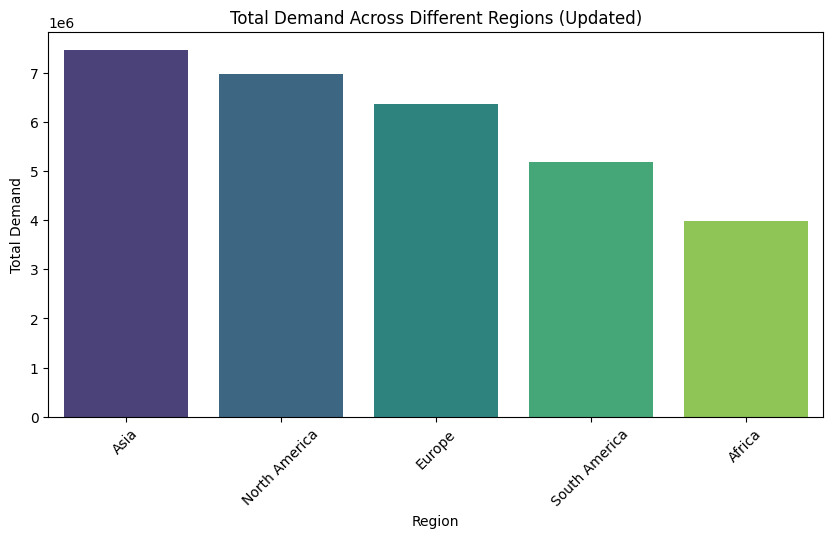

,region,actual_demand
1,Asia,7462149
3,North America,6965119
2,Europe,6368775
4,South America,5190206
0,Africa,3988369


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by region and calculate total demand
region_demand = df.groupby("region")["actual_demand"].sum().reset_index()

# Sort values for better visualization
region_demand = region_demand.sort_values(by="actual_demand", ascending=False)

# Plot demand distribution across regions
plt.figure(figsize=(10, 5))
sns.barplot(x="region", y="actual_demand", data=region_demand, palette="viridis",hue = "region",legend = False)
plt.xlabel("Region")
plt.ylabel("Total Demand")
plt.title("Total Demand Across Different Regions (Updated)")
plt.xticks(rotation=45)
plt.show()

# Display the actual numbers
region_demand


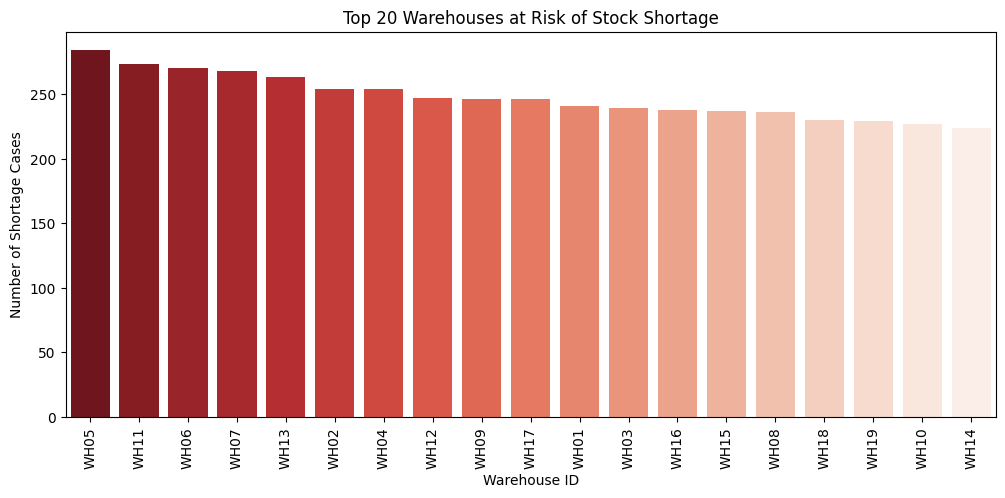

,warehouse_id,shortage_risk
4,WH05,284
10,WH11,273
5,WH06,270
6,WH07,268
12,WH13,263
1,WH02,254
3,WH04,254
11,WH12,247
8,WH09,246
16,WH17,246


In [16]:
# Define a stock shortage threshold (e.g., if stock is less than 20% of actual demand)
df["shortage_risk"] = df["stock_level"] < (0.2 * df["actual_demand"])

# Count warehouses with high shortage risk
shortage_summary = df.groupby("warehouse_id")["shortage_risk"].sum().reset_index()

# Sort warehouses by highest shortage risk
shortage_summary = shortage_summary.sort_values(by="shortage_risk", ascending=False)

# Plot shortage risk per warehouse
plt.figure(figsize=(12, 5))
sns.barplot(x="warehouse_id", y="shortage_risk", data=shortage_summary.head(20), palette="Reds_r",hue="warehouse_id",legend=False)
plt.xlabel("Warehouse ID")
plt.ylabel("Number of Shortage Cases")
plt.title("Top 20 Warehouses at Risk of Stock Shortage")
plt.xticks(rotation=90)
plt.show()

# Display top 10 warehouses with most shortages
shortage_summary.head(10)


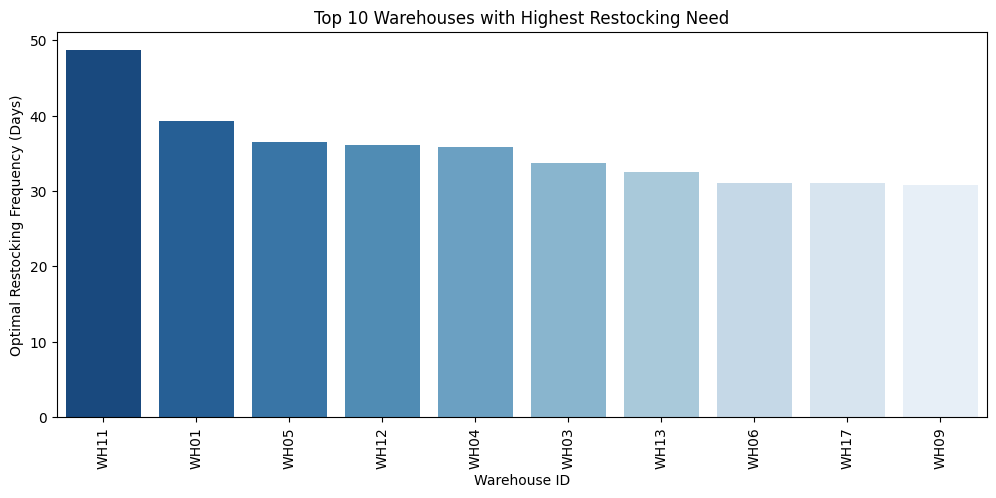

,warehouse_id,restock_frequency
10,WH11,48.684289
0,WH01,39.340118
4,WH05,36.539376
11,WH12,36.126467
3,WH04,35.788111
2,WH03,33.644069
12,WH13,32.528188
5,WH06,31.080562
16,WH17,31.041539
8,WH09,30.784829


In [11]:
# Calculate optimal restocking frequency (in days)
df["restock_frequency"] = (df["actual_demand"] / (df["stock_level"] + 1)) * df["restock_lead_time"]

# Get average restocking frequency per warehouse
restock_summary = df.groupby("warehouse_id")["restock_frequency"].mean().reset_index()

# Sort warehouses by highest restocking need
restock_summary = restock_summary.sort_values(by="restock_frequency", ascending=False)

# Plot restocking frequency for top 10 warehouses
plt.figure(figsize=(12, 5))
sns.barplot(x="warehouse_id", y="restock_frequency", data=restock_summary.head(10), palette="Blues_r",hue="warehouse_id",legend=False)
plt.xlabel("Warehouse ID")
plt.ylabel("Optimal Restocking Frequency (Days)")
plt.title("Top 10 Warehouses with Highest Restocking Need")
plt.xticks(rotation=90)
plt.show()

# Display top 10 warehouses with highest restocking need
restock_summary.head(10)


In [12]:
# Ensure 'order_date' is in datetime format
df["order_date"] = pd.to_datetime(df["order_date"])

# Now extract year and month
df["year_month"] = df["order_date"].dt.to_period("M")


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract year and month from order_date
df["year_month"] = df["order_date"].dt.to_period("M")

# Group by month and sum actual demand
monthly_demand = df.groupby("year_month")["actual_demand"].sum().reset_index()

# Convert period to datetime for plotting
monthly_demand["year_month"] = monthly_demand["year_month"].astype(str)

# Display the first few rows
monthly_demand.head()


,year_month,actual_demand
0,2022-03,461197
1,2022-04,799190
2,2022-05,779567
3,2022-06,861812
4,2022-07,845381


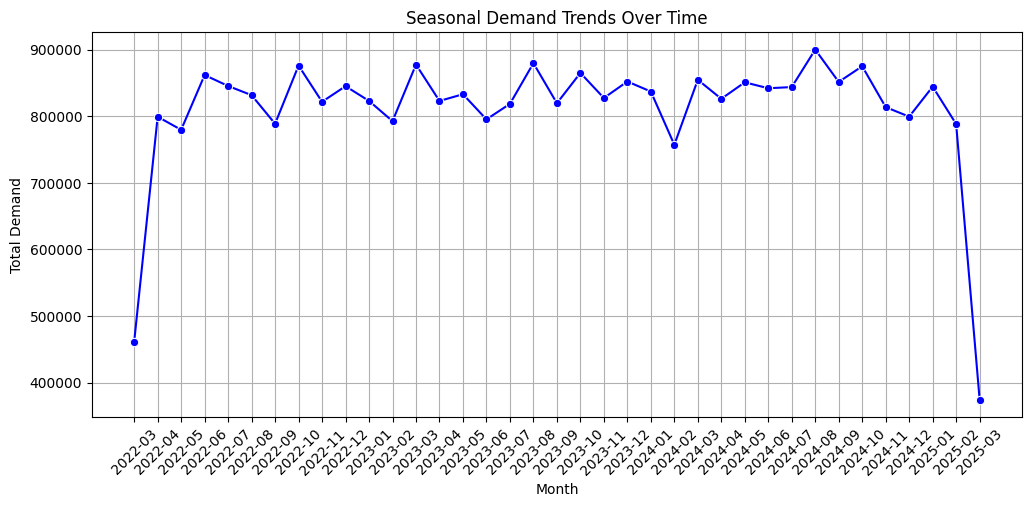

In [14]:
# Plot seasonal trend
plt.figure(figsize=(12, 5))
sns.lineplot(x="year_month", y="actual_demand", data=monthly_demand, marker="o", color="b")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.title("Seasonal Demand Trends Over Time")
plt.grid()
plt.show()


In [15]:
# Display the minimum and maximum order_date to confirm date range
print("Date Range:", df_cleaned["order_date"].min(), "to", df_cleaned["order_date"].max())


Date Range: 2022-03-15 00:00:00 to 2025-03-13 00:00:00


In [16]:
import pandas as pd

# Ensure 'order_date' is in datetime format
df_cleaned["order_date"] = pd.to_datetime(df_cleaned["order_date"])

# Aggregate demand by date (sum actual_demand per day)
daily_demand = df_cleaned.groupby("order_date")["actual_demand"].sum().reset_index()

# Display the first few rows
print(daily_demand.head())


  order_date  actual_demand
0 2022-03-15          32097
1 2022-03-16          17001
2 2022-03-17          24437
3 2022-03-18          24424
4 2022-03-19          27326


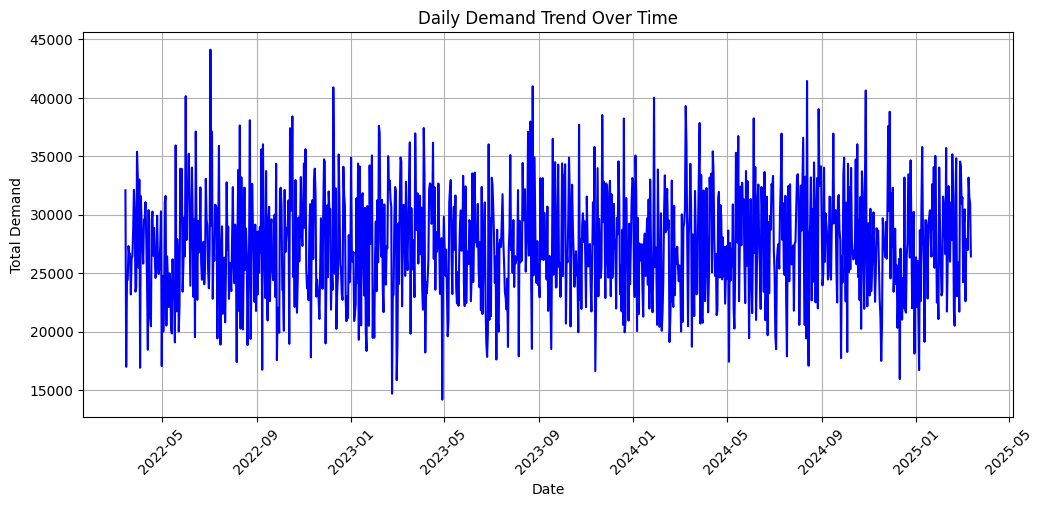

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot demand trend
plt.figure(figsize=(12, 5))
sns.lineplot(x="order_date", y="actual_demand", data=daily_demand, color="b")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.title("Daily Demand Trend Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.show()
